In [22]:
import torch
import os
import pandas as pd
import glob

# Path to the model directory
model_root = '../model/20260131_235234/'

# List to store results
results = []

# Iterate through date directories
for date_id_dir in sorted(os.listdir(model_root)):
    date_path = os.path.join(model_root, date_id_dir)
    if not os.path.isdir(date_path):
        continue
    
    date_id = date_id_dir
    
    # Iterate through lane files
    for lane_file in sorted(glob.glob(os.path.join(date_path, 'best_model_lane*.pt'))):
        lane_name = os.path.basename(lane_file).replace('best_model_', '').replace('.pt', '')
        
        try:
            checkpoint = torch.load(lane_file, map_location='cpu')
            
            # Extract parameters
            params = {
                'date_id': int(date_id),
                'lane': lane_name,
            }
            
            # Add model parameters (convert tensor to float if necessary)
            for k, v in checkpoint.items():
                if torch.is_tensor(v):
                    params[k] = v.item()
                else:
                    params[k] = v
                    
            results.append(params)
            
        except Exception as e:
            print(f"Error loading {lane_file}: {e}")

# Create DataFrame
df = pd.DataFrame(results)

# Sort for better readability
df = df.sort_values(by=['date_id', 'lane'])

# Reorder columns if needed
cols = ['date_id', 'lane', 'tau', 'delta', 'c_cong', 'c_free', 'v_thr', 'v_delta']
# Check if these columns exist to avoid KeyError in case structure is different
cols = [c for c in cols if c in df.columns]
df = df[cols]
df['c_cong'] = -df['c_cong']
df['c_free'] = -df['c_free']
# Round to 2 decimal places
df = df.round(2)
# Load dates from dates.csv
dates_df = pd.read_csv('../dates.csv')
dates_df['date_id'] = range(len(dates_df))

MILE_TO_KM = 1.60934
df['c_cong'] = df['c_cong'] * MILE_TO_KM
df['c_free'] = df['c_free'] * MILE_TO_KM
df['v_delta'] = df['v_delta'] * MILE_TO_KM
df['v_thr'] = df['v_thr'] * MILE_TO_KM
df['delta'] = df['delta'] * MILE_TO_KM

df = df.round(2)

# Merge with the dataframe
df = df.merge(dates_df, on='date_id', how='left')

# Reorder columns to put date first
cols_order = ['date', 'date_id', 'lane'] + [c for c in df.columns if c not in ['date', 'date_id', 'lane']]
df = df[cols_order]

df

# Display
print("Shape:", df.shape)
df

Shape: (20, 9)


/tmp/ipykernel_58355/2353568908.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(lane_file, map_location='cpu')


,date,date_id,lane,tau,delta,c_cong,c_free,v_thr,v_delta
0,2024-07-08,0,lane1,13.14,0.26,-19.60,96.56,93.39,20.26
1,2024-07-08,0,lane2,12.33,0.24,-18.73,96.56,73.64,10.93
2,2024-07-08,0,lane3,14.13,0.23,-18.15,96.56,68.38,11.30
3,2024-07-08,0,lane4,14.75,0.26,-16.98,90.86,59.96,13.73
4,2024-07-09,1,lane1,9.27,0.14,-19.73,81.11,79.77,16.27
5,2024-07-09,1,lane2,7.86,0.14,-20.20,80.16,67.61,12.39
6,2024-07-09,1,lane3,8.23,0.14,-21.02,81.46,65.92,13.18
7,2024-07-09,1,lane4,11.56,0.16,-20.57,96.56,59.42,14.19
8,2024-07-10,2,lane1,9.32,0.14,-20.23,78.87,78.54,16.91
9,2024-07-10,2,lane2,7.00,0.14,-21.61,79.63,68.32,11.86


Saved: ../figures/summary_d2d/tau.pdf


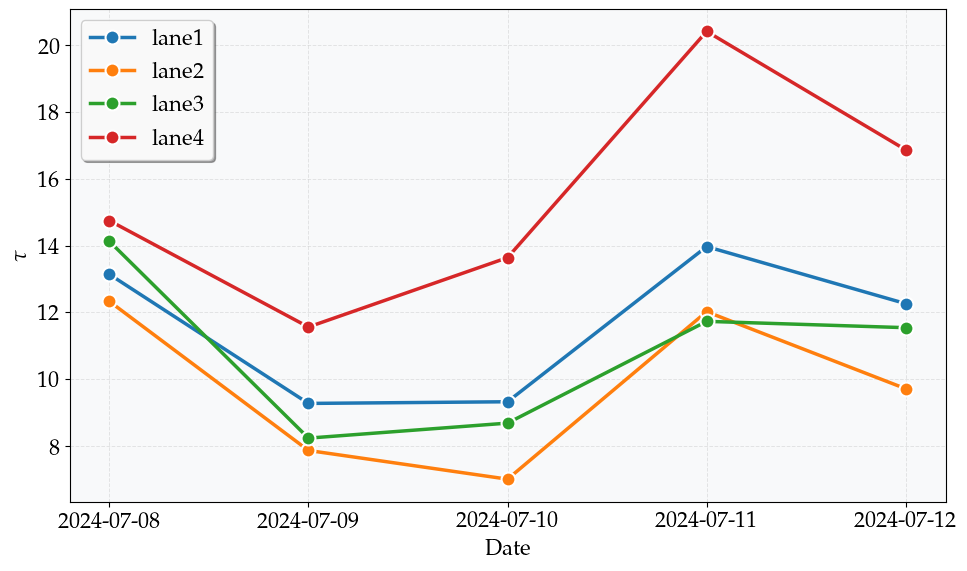

Saved: ../figures/summary_d2d/delta.pdf


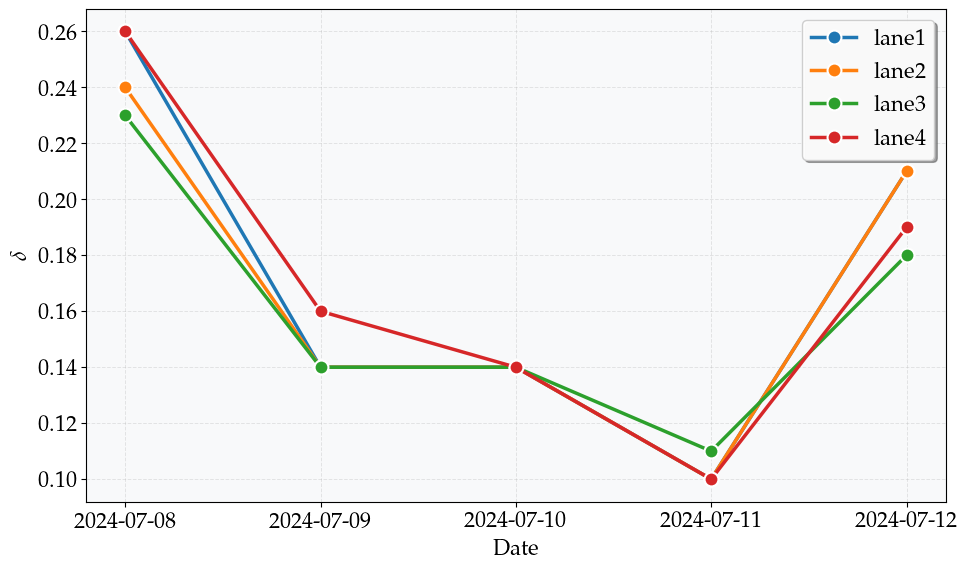

Saved: ../figures/summary_d2d/c_cong.pdf


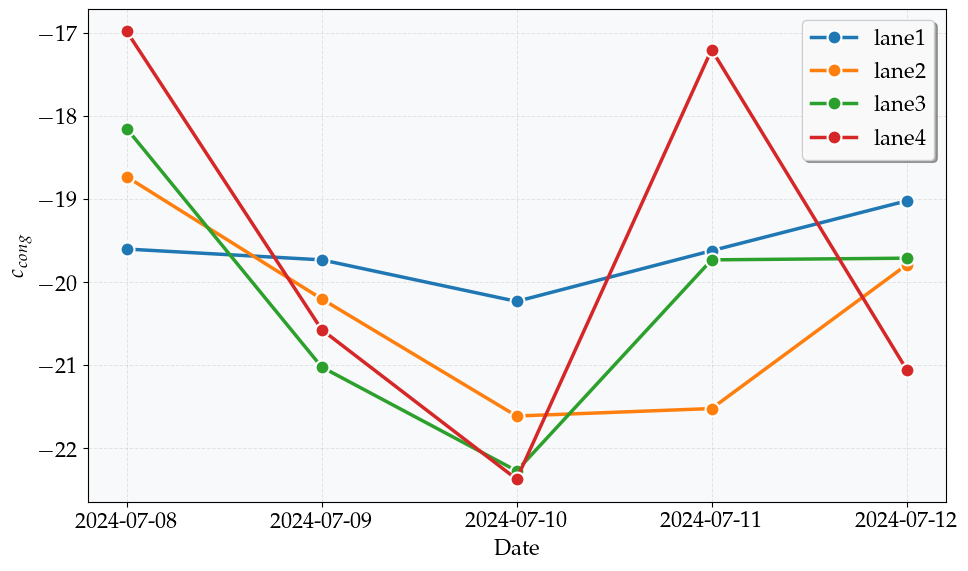

Saved: ../figures/summary_d2d/c_free.pdf


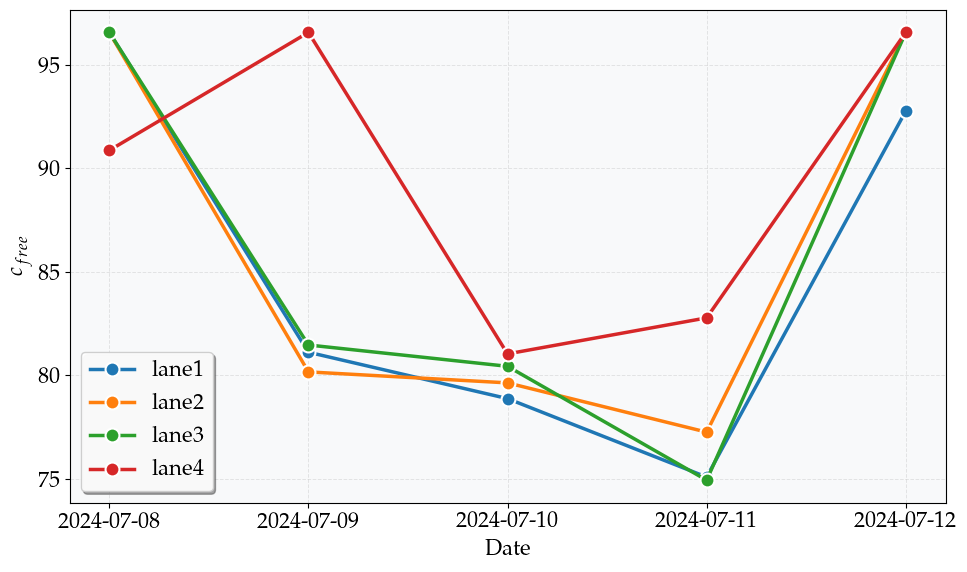

Saved: ../figures/summary_d2d/v_thr.pdf


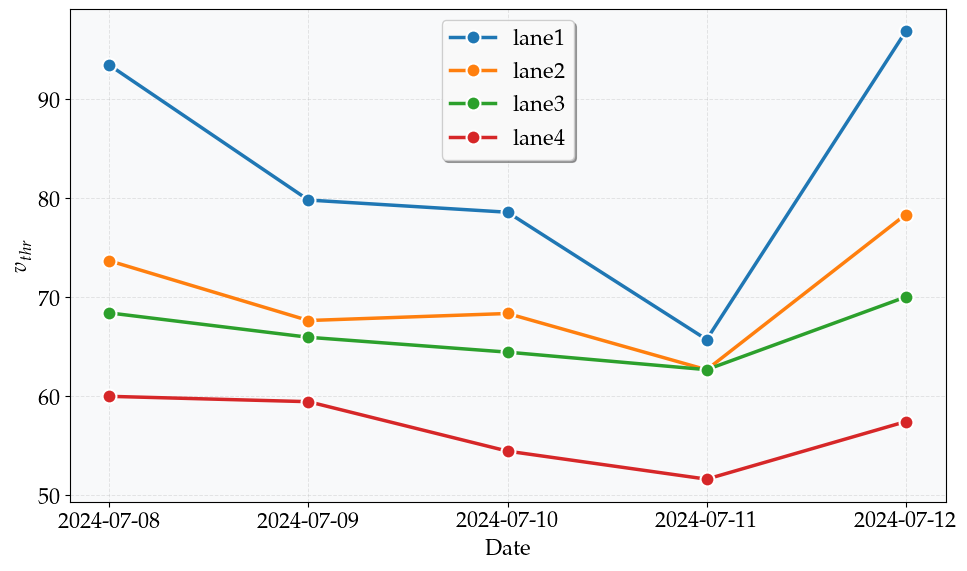

Saved: ../figures/summary_d2d/v_delta.pdf


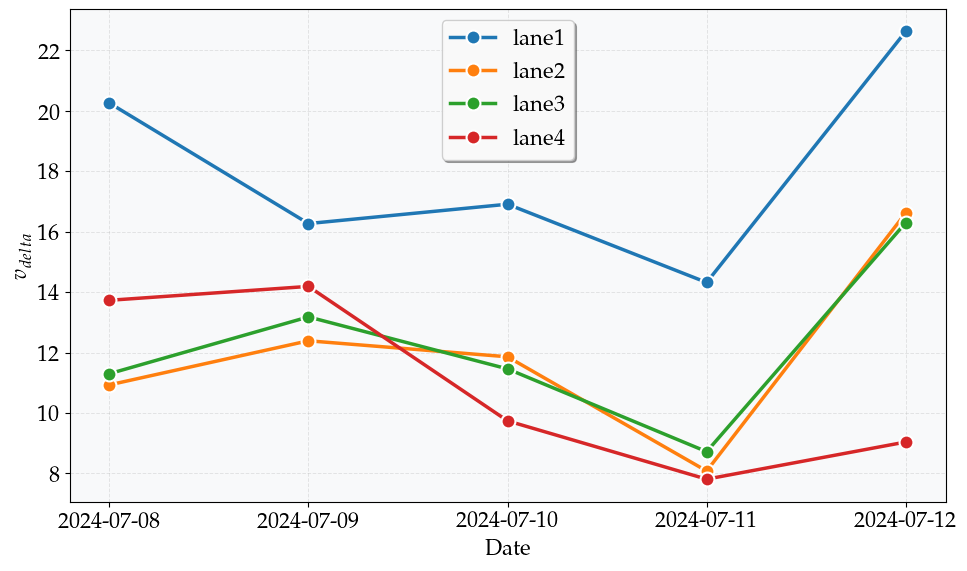


All figures saved to ../figures/summary_d2d/


In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Configure matplotlib for LaTeX rendering and Palatino font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino']
plt.rcParams['font.size'] = 16

# Create mapping for parameter labels
param_labels = {
    'tau': r'$\tau$',
    'delta': r'$\delta$',
    'c_cong': r'$c_{cong}$',
    'c_free': r'$c_{free}$',
    'v_thr': r'$v_{thr}$',
    'v_delta': r'$v_{delta}$'
}

# Define fancy color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Classic matplotlib colors enhanced

# Get the numeric columns (exclude date_id, lane, and date)
numeric_cols = [col for col in df.columns if col not in ['date_id', 'lane', 'date']]

# Get unique lanes
lanes = df['lane'].unique()

# Create output directory if it doesn't exist
import os
os.makedirs('../figures/summary_d2d', exist_ok=True)

# Plot and save each parameter separately
for param in numeric_cols:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for idx, lane in enumerate(sorted(lanes)):
        lane_data = df[df['lane'] == lane].sort_values('date_id')
        color = colors[idx % len(colors)]
        ax.plot(lane_data['date'], lane_data[param], marker='o', label=lane,
                linewidth=2.5, markersize=10, color=color, markeredgecolor='white', 
                markeredgewidth=1.5)
    
    ax.set_xlabel('Date', fontsize=16)
    ylabel = param_labels.get(param, param)
    ax.set_ylabel(ylabel, fontsize=16)
    # ax.set_title(f'{param} Day by Day', fontsize=14)
    ax.legend(fontsize=16, framealpha=0.95, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_facecolor('#f8f9fa')
    plt.xticks(rotation=0)
    plt.tight_layout()
    
    # Save figure
    fig_path = f'../figures/summary_d2d/{param}.pdf'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight', format='pdf')
    print(f"Saved: {fig_path}")
    
    plt.show()

print(f"\nAll figures saved to ../figures/summary_d2d/")